# Stage 7 — Train-Only Feature Selection and Final Dataset Construction

## 7.1 Training-only Spearman screening

In [680]:
train_level_for_selection = level_2022_pool[level_2022_pool["country_code"].isin(train_codes)].merge(
    train_country_df[["country_code", "log_u5mr_2023"]],
    on="country_code",
    how="inner"
)

selection_rows = []
for (code_value, name_value), group in train_level_for_selection.groupby(["indicator_code", "indicator_name"]):
    valid = group[[LEVEL_VALUE_COLUMN, "log_u5mr_2023"]].dropna()
    if len(valid) >= 40 and valid[LEVEL_VALUE_COLUMN].nunique() > 1:
        corr_value = valid[LEVEL_VALUE_COLUMN].corr(valid["log_u5mr_2023"], method="spearman")
    else:
        corr_value = np.nan
    selection_rows.append({
        "indicator_code": code_value,
        "indicator_name": name_value,
        "train_spearman_corr": corr_value,
        "abs_corr": abs(corr_value) if pd.notna(corr_value) else np.nan,
        "train_valid_pairs": len(valid)
    })

train_correlations = pd.DataFrame(selection_rows).merge(
    eligible_indicators[["indicator_code", "missing_pct", "source_year"]],
    on="indicator_code",
    how="left"
)

candidate_60 = (
    train_correlations
    .dropna(subset=["abs_corr"])
    .sort_values("abs_corr", ascending=False)
    .head(CANDIDATE_LIMIT)
    .copy()
)
candidate_60["candidate_rank"] = range(1, len(candidate_60) + 1)

candidate_60.to_csv(TABLE_DIR / "candidate_60_indicators_train_only_2022.csv", index=False)

display(candidate_60[["candidate_rank", "indicator_name", "missing_pct", "train_spearman_corr", "abs_corr", "train_valid_pairs"]].head(20))

,candidate_rank,indicator_name,missing_pct,train_spearman_corr,abs_corr,train_valid_pairs
603,1,"Current health expenditure per capita, PPP (cu...",0.030612,-0.890140,0.890140,142
611,2,Domestic general government health expenditure...,0.030612,-0.888415,0.888415,142
723,3,"Birth rate, crude (per 1,000 people)",0.000000,0.884283,0.884283,147
300,4,Fixed broadband subscriptions (per 100 people),0.025510,-0.880805,0.880805,143
573,5,Risk of impoverishing expenditure for surgical...,0.423469,0.878992,0.878992,82
732,6,Population ages 0-14 (% of total population),0.000000,0.877666,0.877666,147
728,7,"Population ages 0-14, female (% of female popu...",0.000000,0.872016,0.872016,147
610,8,Domestic general government health expenditure...,0.030612,-0.871714,0.871714,143
449,9,"GNI per capita, PPP (constant 2021 internation...",0.219388,-0.870400,0.870400,115
602,10,Current health expenditure per capita (current...,0.030612,-0.869727,0.869727,143


## 7.2 Remove redundant indicators using training data only

In [682]:
candidate_codes = candidate_60["indicator_code"].tolist()

candidate_train_matrix = (
    level_2022_pool[
        level_2022_pool["country_code"].isin(train_codes)
        & level_2022_pool["indicator_code"].isin(candidate_codes)
    ]
    .pivot(index="country_code", columns="indicator_code", values=LEVEL_VALUE_COLUMN)
    .reindex(columns=candidate_codes)
)

candidate_redundancy_corr = candidate_train_matrix.corr(method="spearman").abs()

selected_codes = []
redundancy_rows = []

for _, row in candidate_60.iterrows():
    code_value = row["indicator_code"]
    name_value = row["indicator_name"]

    if len(selected_codes) == 0:
        selected_codes.append(code_value)
        redundancy_rows.append({
            "indicator_code": code_value,
            "indicator_name": name_value,
            "decision": "selected",
            "max_abs_corr_with_selected": np.nan
        })
    else:
        max_corr = candidate_redundancy_corr.loc[code_value, selected_codes].max(skipna=True)
        if pd.isna(max_corr) or max_corr < REDUNDANCY_LIMIT:
            selected_codes.append(code_value)
            decision = "selected"
        else:
            decision = "excluded_redundant"

        redundancy_rows.append({
            "indicator_code": code_value,
            "indicator_name": name_value,
            "decision": decision,
            "max_abs_corr_with_selected": max_corr
        })

    if len(selected_codes) >= FINAL_INDICATOR_LIMIT:
        break

redundancy_audit = pd.DataFrame(redundancy_rows)
final_indicators = candidate_60[candidate_60["indicator_code"].isin(selected_codes)].copy()
final_indicators["final_rank"] = range(1, len(final_indicators) + 1)

print("Selected original WDI indicators:", len(final_indicators))
print("Maximum allowed original WDI indicators:", FINAL_INDICATOR_LIMIT)

display(final_indicators[["final_rank", "indicator_name", "missing_pct", "train_spearman_corr", "abs_corr"]])

Selected original WDI indicators: 18
Maximum allowed original WDI indicators: 25


,final_rank,indicator_name,missing_pct,train_spearman_corr,abs_corr
603,1,"Current health expenditure per capita, PPP (cu...",0.030612,-0.890140,0.890140
723,2,"Birth rate, crude (per 1,000 people)",0.000000,0.884283,0.884283
300,3,Fixed broadband subscriptions (per 100 people),0.025510,-0.880805,0.880805
302,4,Secure Internet servers (per 1 million people),0.005102,-0.852474,0.852474
776,5,"Population ages 80 and above, male (% of male ...",0.000000,-0.844607,0.844607
720,6,Prevalence of moderate or severe food insecuri...,0.260204,0.841557,0.841557
738,7,"Population ages 15-19, male (% of male populat...",0.000000,0.838677,0.838677
549,8,People using at least basic drinking water ser...,0.056122,-0.836031,0.836031
566,9,"Physicians (per 1,000 people)",0.362245,-0.835177,0.835177
575,10,People using at least basic sanitation service...,0.132653,-0.832553,0.832553


## 7.3 Predictor names and domains

### 7.3.1 Group indicators by domain

In [685]:
def classify_indicator_domain(indicator_name):
    """Assign each WDI indicator to a broad interpretable domain."""
    name = str(indicator_name).lower()

    if any(term in name for term in [
        "health expenditure", "physician", "nurse", "midwife", "hospital",
        "immunization", "vaccine", "anemia", "uhc", "service coverage",
        "medical", "surgical"
    ]):
        return "health system"

    if any(term in name for term in [
        "water", "sanitation", "electric", "internet", "broadband", "server"
    ]):
        return "infrastructure"

    if any(term in name for term in [
        "gdp", "gni", "income", "poverty", "employment", "wage",
        "consumption", "prosperity"
    ]):
        return "economic"

    if any(term in name for term in [
        "population", "birth rate", "fertility", "age", "urban",
        "rural", "adolescent"
    ]):
        return "demographic"

    if any(term in name for term in [
        "school", "education", "literacy", "reading", "learning",
        "pupil", "food", "undernourishment", "nutrition"
    ]):
        return "education/social"

    return "other"


### 7.3.2 Create concise predictor names

In [687]:
def make_simple_indicator_name(indicator_name, indicator_code, used_names):
    """Create short, clear predictor names for modeling outputs and plots."""
    name = str(indicator_name).lower()

    if "anemia" in name and "children" in name:
        base = "child_anemia"
    elif "birth rate" in name:
        base = "birth_rate"
    elif "adolescent fertility" in name:
        base = "adolescent_fertility"
    elif "fertility" in name:
        base = "fertility"
    elif "at least basic drinking water" in name or "drinking water" in name:
        base = "water_access"
    elif "at least basic sanitation" in name or "sanitation" in name:
        base = "sanitation_access"
    elif "access to electricity" in name or "electric" in name:
        base = "electricity_access"
    elif "school enrollment" in name and "secondary" in name:
        base = "secondary_school"
    elif "school enrollment" in name and "primary" in name:
        base = "primary_school"
    elif "reading proficiency" in name or "learning poverty" in name:
        base = "reading_proficiency"
    elif "literacy" in name:
        base = "literacy"
    elif "bottom 40" in name and "income" in name:
        base = "income_bottom40"
    elif "income per capita" in name:
        base = "income_pc"
    elif "gdp per capita" in name:
        base = "gdp_pc"
    elif "gni per capita" in name:
        base = "gni_pc"
    elif "poverty" in name:
        base = "poverty"
    elif "food insecurity" in name:
        base = "food_insecurity"
    elif "undernourishment" in name:
        base = "undernourishment"
    elif "physicians" in name:
        base = "physicians"
    elif "nurses" in name or "midwives" in name:
        base = "nurses_midwives"
    elif "health expenditure" in name:
        base = "health_exp"
    elif "population ages 80 and above" in name:
        base = "elderly_share"
    elif "population ages 15-19" in name:
        base = "youth_15_19_share"
    elif "population ages 0-14" in name:
        base = "children_share"
    elif "secure internet servers" in name:
        base = "secure_servers"
    elif "individuals using the internet" in name:
        base = "internet_use"
    elif "wage and salaried workers" in name:
        base = "wage_salaried_workers"
    elif "researchers in r&d" in name or "researchers" in name:
        base = "researchers_rd"
    else:
        words = re.findall(r"[a-z]+", name)
        stop_words = {
            "the", "and", "for", "with", "from", "into", "per", "of", "in",
            "to", "by", "at", "as", "total", "current", "constant",
            "annual", "percentage", "percent", "people", "population",
            "female", "male", "modeled", "estimate", "international",
            "dollars", "2017", "ppp"
        }
        important_words = [
            word for word in words
            if word not in stop_words and len(word) > 2
        ][:3]
        base = "_".join(important_words) if important_words else str(indicator_code).lower()

    base = re.sub(r"[^a-z0-9]+", "_", base).strip("_")[:30]

    candidate = base
    counter = 2
    while candidate in used_names:
        candidate = f"{base}_{counter}"
        counter += 1

    used_names.add(candidate)
    return candidate


### 7.3.3 Apply names and save the indicator dictionary

In [689]:
used_simple_names = set()

final_indicators["domain"] = final_indicators["indicator_name"].apply(classify_indicator_domain)

final_indicators["simple_name"] = [
    make_simple_indicator_name(name, code, used_simple_names)
    for name, code in zip(final_indicators["indicator_name"], final_indicators["indicator_code"])
]

final_indicator_dictionary = final_indicators[[
    "final_rank",
    "simple_name",
    "domain",
    "indicator_code",
    "indicator_name",
    "missing_pct",
    "train_spearman_corr",
    "abs_corr",
    "train_valid_pairs"
]].copy()

final_indicator_dictionary.to_csv(
    TABLE_DIR / "final_indicator_dictionary_clear_train_only.csv",
    index=False
)
redundancy_audit.to_csv(TABLE_DIR / "redundancy_audit_train_only.csv", index=False)

print("Selected original WDI indicators:", len(final_indicator_dictionary))
display(final_indicator_dictionary)


Selected original WDI indicators: 18


,final_rank,simple_name,domain,indicator_code,indicator_name,missing_pct,train_spearman_corr,abs_corr,train_valid_pairs
603,1,health_exp,health system,WB_WDI_SH_XPD_CHEX_PP_CD,"Current health expenditure per capita, PPP (cu...",0.030612,-0.890140,0.890140,142
723,2,birth_rate,demographic,WB_WDI_SP_DYN_CBRT_IN,"Birth rate, crude (per 1,000 people)",0.000000,0.884283,0.884283,147
300,3,fixed_broadband_subscriptions,infrastructure,WB_WDI_IT_NET_BBND_P2,Fixed broadband subscriptions (per 100 people),0.025510,-0.880805,0.880805,143
302,4,secure_servers,infrastructure,WB_WDI_IT_NET_SECR_P6,Secure Internet servers (per 1 million people),0.005102,-0.852474,0.852474,146
776,5,elderly_share,demographic,WB_WDI_SP_POP_80UP_MA_5Y,"Population ages 80 and above, male (% of male ...",0.000000,-0.844607,0.844607,147
720,6,food_insecurity,demographic,WB_WDI_SN_ITK_MSFI_ZS,Prevalence of moderate or severe food insecuri...,0.260204,0.841557,0.841557,109
738,7,youth_15_19_share,demographic,WB_WDI_SP_POP_1519_MA_5Y,"Population ages 15-19, male (% of male populat...",0.000000,0.838677,0.838677,147
549,8,water_access,infrastructure,WB_WDI_SH_H2O_BASW_ZS,People using at least basic drinking water ser...,0.056122,-0.836031,0.836031,140
566,9,physicians,health system,WB_WDI_SH_MED_PHYS_ZS,"Physicians (per 1,000 people)",0.362245,-0.835177,0.835177,93
575,10,sanitation_access,infrastructure,WB_WDI_SH_STA_BASS_UR_ZS,People using at least basic sanitation service...,0.132653,-0.832553,0.832553,129


## 7.4 Create final 2022-level and 2018-to-2022-change features

In [691]:
final_code_to_name = dict(zip(final_indicators["indicator_code"], final_indicators["simple_name"]))
final_codes = list(final_code_to_name.keys())

level_final_long = level_2022_pool[level_2022_pool["indicator_code"].isin(final_codes)].copy()
level_final_long["feature"] = level_final_long["indicator_code"].map(final_code_to_name) + f"_{PREDICTOR_LEVEL_YEAR}"

change_final_long = change_2018_2022_pool[change_2018_2022_pool["indicator_code"].isin(final_codes)].copy()
change_final_long["feature"] = (
    change_final_long["indicator_code"].map(final_code_to_name)
    + f"_change_{CHANGE_START_YEAR}_{CHANGE_END_YEAR}"
)

level_wide = level_final_long.pivot(index="country_code", columns="feature", values=LEVEL_VALUE_COLUMN)
change_wide = change_final_long.pivot(index="country_code", columns="feature", values=CHANGE_VALUE_COLUMN)

model_data_full = target_df.set_index("country_code").join([level_wide, change_wide], how="left").reset_index()

level_suffix = f"_{PREDICTOR_LEVEL_YEAR}"
change_suffix = f"_change_{CHANGE_START_YEAR}_{CHANGE_END_YEAR}"
feature_columns_all = [
    col for col in model_data_full.columns
    if col.endswith(level_suffix) or col.endswith(change_suffix)
]

print("Original WDI indicators selected:", len(final_indicators))
print("Engineered predictor columns before final missingness filter:", len(feature_columns_all))
print("Example feature names:", feature_columns_all[:8])

Original WDI indicators selected: 18
Engineered predictor columns before final missingness filter: 36
Example feature names: ['adolescent_fertility_2022', 'birth_rate_2022', 'elderly_share_2022', 'fixed_broadband_subscriptions_2022', 'food_insecurity_2022', 'health_exp_2022', 'living_slums_urban_2022', 'nurses_midwives_2022']


## 7.5 Final predictor filtering

The selected original WDI indicators are converted into two possible engineered predictors: a 2022 value and a 2018–2022 change.  
To keep the final cross-sectional model interpretable and suitable for the sample size, the final engineered predictor set is restricted to **25 columns or fewer**.

This step uses training countries only to:

1. remove engineered predictors with more than 50% missingness;
2. rank remaining predictors by Spearman correlation with `log_u5mr_2023`;
3. remove highly redundant engineered predictors;
4. keep at most 25 final predictor columns.

In [693]:
train_mask_for_missingness = model_data_full["country_code"].isin(train_codes)

# Missingness is calculated using training countries only.
final_feature_missingness = pd.DataFrame({
    "feature": feature_columns_all,
    "missing_pct_train": model_data_full.loc[train_mask_for_missingness, feature_columns_all].isna().mean().values,
    "missing_pct_all": model_data_full[feature_columns_all].isna().mean().values
}).sort_values("missing_pct_train", ascending=False)

features_after_missingness = final_feature_missingness[
    final_feature_missingness["missing_pct_train"] <= MAX_FINAL_FEATURE_MISSINGNESS
]["feature"].tolist()

dropped_high_missing_features = final_feature_missingness[
    final_feature_missingness["missing_pct_train"] > MAX_FINAL_FEATURE_MISSINGNESS
].copy()

# Rank engineered predictors by their training-only association with the target.
train_feature_screening_data = model_data_full.loc[
    train_mask_for_missingness,
    features_after_missingness + ["log_u5mr_2023"]
].copy()

engineered_selection_rows = []

for feature in features_after_missingness:
    valid = train_feature_screening_data[[feature, "log_u5mr_2023"]].dropna()

    if len(valid) >= 40 and valid[feature].nunique() > 1:
        corr_value = valid[feature].corr(valid["log_u5mr_2023"], method="spearman")
    else:
        corr_value = np.nan

    engineered_selection_rows.append({
        "feature": feature,
        "train_spearman_corr": corr_value,
        "abs_corr": abs(corr_value) if pd.notna(corr_value) else np.nan,
        "train_valid_pairs": len(valid)
    })

engineered_feature_screening = (
    pd.DataFrame(engineered_selection_rows)
    .merge(final_feature_missingness, on="feature", how="left")
    .dropna(subset=["abs_corr"])
    .sort_values("abs_corr", ascending=False)
    .reset_index(drop=True)
)

# Remove redundancy among engineered predictors using training data only.
ranked_engineered_features = engineered_feature_screening["feature"].tolist()
engineered_redundancy_corr = (
    train_feature_screening_data[ranked_engineered_features]
    .corr(method="spearman")
    .abs()
)

kept_feature_columns = []
engineered_feature_selection_audit = []

for _, row in engineered_feature_screening.iterrows():
    feature = row["feature"]

    if len(kept_feature_columns) == 0:
        max_corr_with_selected = np.nan
    else:
        max_corr_with_selected = engineered_redundancy_corr.loc[
            feature,
            kept_feature_columns
        ].max(skipna=True)

    if len(kept_feature_columns) >= FINAL_ENGINEERED_FEATURE_LIMIT:
        decision = "excluded_limit_25"
    elif pd.notna(max_corr_with_selected) and max_corr_with_selected >= ENGINEERED_REDUNDANCY_LIMIT:
        decision = "excluded_redundant"
    else:
        decision = "selected"
        kept_feature_columns.append(feature)

    engineered_feature_selection_audit.append({
        "feature": feature,
        "decision": decision,
        "train_spearman_corr": row["train_spearman_corr"],
        "abs_corr": row["abs_corr"],
        "train_valid_pairs": row["train_valid_pairs"],
        "missing_pct_train": row["missing_pct_train"],
        "missing_pct_all": row["missing_pct_all"],
        "max_abs_corr_with_selected": max_corr_with_selected
    })

engineered_feature_selection_audit = pd.DataFrame(engineered_feature_selection_audit)

selected_engineered_features = engineered_feature_selection_audit[
    engineered_feature_selection_audit["decision"] == "selected"
].copy()

dropped_engineered_features = engineered_feature_selection_audit[
    engineered_feature_selection_audit["decision"] != "selected"
].copy()

# Keep only final selected predictors in the modeling table.
model_data = model_data_full[[
    "country_code", "country_name", "u5mr_2023", "log_u5mr_2023"
] + kept_feature_columns].copy()

# Original WDI indicators represented by at least one final engineered predictor.
used_simple_names_final = set()
level_suffix = f"_{PREDICTOR_LEVEL_YEAR}"
change_suffix = f"_change_{CHANGE_START_YEAR}_{CHANGE_END_YEAR}"

for feature in kept_feature_columns:
    if feature.endswith(change_suffix):
        used_simple_names_final.add(feature[:-len(change_suffix)])
    elif feature.endswith(level_suffix):
        used_simple_names_final.add(feature[:-len(level_suffix)])

final_used_indicators = final_indicators[
    final_indicators["simple_name"].isin(used_simple_names_final)
].copy()

# Save audit files.
final_feature_missingness.to_csv(TABLE_DIR / "final_feature_missingness_train_based.csv", index=False)
dropped_high_missing_features.to_csv(TABLE_DIR / "dropped_high_missing_engineered_features.csv", index=False)
engineered_feature_screening.to_csv(TABLE_DIR / "engineered_feature_screening_train_only.csv", index=False)
engineered_feature_selection_audit.to_csv(TABLE_DIR / "engineered_feature_selection_audit_train_only.csv", index=False)
selected_engineered_features.to_csv(TABLE_DIR / "selected_engineered_predictors_train_only.csv", index=False)
dropped_engineered_features.to_csv(TABLE_DIR / "dropped_engineered_predictors_after_screening.csv", index=False)
final_used_indicators.to_csv(TABLE_DIR / "final_used_original_indicators.csv", index=False)

print("Engineered predictor columns before missingness filter:", len(feature_columns_all))
print("Engineered predictor columns after <=50% training missingness:", len(features_after_missingness))
print("Final engineered predictor columns used in models:", len(kept_feature_columns))
print("Maximum allowed engineered predictor columns:", FINAL_ENGINEERED_FEATURE_LIMIT)
print("Original WDI indicators represented in final predictors:", len(final_used_indicators))
print("Engineered predictor columns dropped for >50% training missingness:", len(dropped_high_missing_features))
print("Engineered predictor columns dropped after redundancy/limit filtering:", len(dropped_engineered_features))

assert len(kept_feature_columns) <= FINAL_ENGINEERED_FEATURE_LIMIT

display(selected_engineered_features[[
    "feature",
    "decision",
    "train_spearman_corr",
    "abs_corr",
    "missing_pct_train",
    "max_abs_corr_with_selected"
]])


Engineered predictor columns before missingness filter: 36
Engineered predictor columns after <=50% training missingness: 36
Final engineered predictor columns used in models: 25
Maximum allowed engineered predictor columns: 25
Original WDI indicators represented in final predictors: 18
Engineered predictor columns dropped for >50% training missingness: 0
Engineered predictor columns dropped after redundancy/limit filtering: 11


,feature,decision,train_spearman_corr,abs_corr,missing_pct_train,max_abs_corr_with_selected
0,health_exp_2022,selected,-0.890140,0.890140,0.034014,NaN
1,birth_rate_2022,selected,0.884283,0.884283,0.000000,0.863934
2,fixed_broadband_subscriptions_2022,selected,-0.880805,0.880805,0.027211,0.893245
3,secure_servers_2022,selected,-0.852474,0.852474,0.006803,0.872781
4,elderly_share_2022,selected,-0.844607,0.844607,0.000000,0.876073
5,food_insecurity_2022,selected,0.841557,0.841557,0.258503,0.824077
6,youth_15_19_share_2022,selected,0.838677,0.838677,0.000000,0.897645
7,water_access_2022,selected,-0.836031,0.836031,0.047619,0.877142
8,physicians_2022,selected,-0.835177,0.835177,0.367347,0.882415
9,sanitation_access_2022,selected,-0.832553,0.832553,0.122449,0.859036


## 7.6 Predictor dictionary

In [695]:
indicator_lookup = final_indicators.set_index("simple_name").to_dict(orient="index")

feature_dictionary_rows = []
level_suffix = f"_{PREDICTOR_LEVEL_YEAR}"
change_suffix = f"_change_{CHANGE_START_YEAR}_{CHANGE_END_YEAR}"

for feature in kept_feature_columns:
    # Important: check the longer change suffix first.
    # Example: birth_rate_change_2018_2022 also ends with _2022.
    if feature.endswith(change_suffix):
        simple_name = feature[:-len(change_suffix)]
        feature_type = f"change from {CHANGE_START_YEAR} to {CHANGE_END_YEAR}"
        interpretation_suffix = f"change between {CHANGE_START_YEAR} and {CHANGE_END_YEAR}"
    elif feature.endswith(level_suffix):
        simple_name = feature[:-len(level_suffix)]
        feature_type = f"value in {PREDICTOR_LEVEL_YEAR}"
        interpretation_suffix = f"measured in {PREDICTOR_LEVEL_YEAR}"
    else:
        raise ValueError(f"Unexpected feature name format: {feature}")

    if simple_name not in indicator_lookup:
        available_examples = sorted(indicator_lookup.keys())[:10]
        raise KeyError(
            f"Could not find '{simple_name}' in final indicator lookup. "
            f"Check feature naming. Example available names: {available_examples}"
        )

    info = indicator_lookup[simple_name]
    feature_dictionary_rows.append({
        "feature": feature,
        "predictor_name": simple_name,
        "feature_type": feature_type,
        "domain": info["domain"],
        "indicator_code": info["indicator_code"],
        "indicator_name": info["indicator_name"],
        "interpretation": f"{info['indicator_name']} — {interpretation_suffix}",
        "train_missing_pct": final_feature_missingness.loc[
            final_feature_missingness["feature"] == feature, "missing_pct_train"
        ].iloc[0]
    })

feature_dictionary = (
    pd.DataFrame(feature_dictionary_rows)
    .sort_values(["domain", "predictor_name", "feature_type"])
    .reset_index(drop=True)
)

feature_dictionary.to_csv(TABLE_DIR / "final_predictor_dictionary.csv", index=False)

print("Original WDI indicators represented in final predictors:", len(final_used_indicators))
print("Final engineered predictor columns used in models:", len(kept_feature_columns))
display(feature_dictionary)

Original WDI indicators represented in final predictors: 18
Final engineered predictor columns used in models: 25


,feature,predictor_name,feature_type,domain,indicator_code,indicator_name,interpretation,train_missing_pct
0,adolescent_fertility_2022,adolescent_fertility,value in 2022,demographic,WB_WDI_SP_ADO_TFRT,"Adolescent fertility rate (births per 1,000 wo...","Adolescent fertility rate (births per 1,000 wo...",0.000000
1,birth_rate_2022,birth_rate,value in 2022,demographic,WB_WDI_SP_DYN_CBRT_IN,"Birth rate, crude (per 1,000 people)","Birth rate, crude (per 1,000 people) — measure...",0.000000
2,elderly_share_change_2018_2022,elderly_share,change from 2018 to 2022,demographic,WB_WDI_SP_POP_80UP_MA_5Y,"Population ages 80 and above, male (% of male ...","Population ages 80 and above, male (% of male ...",0.000000
3,elderly_share_2022,elderly_share,value in 2022,demographic,WB_WDI_SP_POP_80UP_MA_5Y,"Population ages 80 and above, male (% of male ...","Population ages 80 and above, male (% of male ...",0.000000
4,food_insecurity_2022,food_insecurity,value in 2022,demographic,WB_WDI_SN_ITK_MSFI_ZS,Prevalence of moderate or severe food insecuri...,Prevalence of moderate or severe food insecuri...,0.258503
5,living_slums_urban_2022,living_slums_urban,value in 2022,demographic,WB_WDI_EN_POP_SLUM_UR_ZS,Population living in slums (% of urban populat...,Population living in slums (% of urban populat...,0.122449
6,practicing_open_defecation_change_2018_2022,practicing_open_defecation,change from 2018 to 2022,demographic,WB_WDI_SH_STA_ODFC_ZS,People practicing open defecation (% of popula...,People practicing open defecation (% of popula...,0.095238
7,practicing_open_defecation_2022,practicing_open_defecation,value in 2022,demographic,WB_WDI_SH_STA_ODFC_ZS,People practicing open defecation (% of popula...,People practicing open defecation (% of popula...,0.095238
8,prevalence_stunting_height_2022,prevalence_stunting_height,value in 2022,demographic,WB_WDI_SH_STA_STNT_ME_MA_ZS,"Prevalence of stunting, height for age, male (...","Prevalence of stunting, height for age, male (...",0.142857
9,youth_15_19_share_2022,youth_15_19_share,value in 2022,demographic,WB_WDI_SP_POP_1519_MA_5Y,"Population ages 15-19, male (% of male populat...","Population ages 15-19, male (% of male populat...",0.000000


## 7.7 Leakage audit

In [697]:
# Temporal leakage audit: level predictors must come from 2022, which is before the 2023 target.
level_source_check = level_final_long[level_final_long["feature"].isin(kept_feature_columns)].copy()
level_violations = level_source_check[level_source_check["source_year"] >= TARGET_YEAR]
wrong_level_year = level_source_check[level_source_check["source_year"] != PREDICTOR_LEVEL_YEAR]

# Temporal leakage audit: change windows must end before 2023.
change_source_check = change_final_long[change_final_long["feature"].isin(kept_feature_columns)].copy()
change_violations = change_source_check[change_source_check["change_end_year"] >= TARGET_YEAR]
wrong_change_window = change_source_check[
    (change_source_check["change_start_year"] != CHANGE_START_YEAR)
    | (change_source_check["change_end_year"] != CHANGE_END_YEAR)
]

# Selection leakage audit: correlation screening must use training countries only.
selection_country_set = set(train_level_for_selection["country_code"].unique())
selection_test_overlap = selection_country_set.intersection(test_codes)

print("2022-level temporal leakage violations:", len(level_violations))
print("Wrong level-year rows:", len(wrong_level_year))
print("Change-window temporal leakage violations:", len(change_violations))
print("Wrong change-window rows:", len(wrong_change_window))
print("Test countries used in supervised indicator screening:", len(selection_test_overlap))

assert len(level_violations) == 0
assert len(wrong_level_year) == 0
assert len(change_violations) == 0
assert len(wrong_change_window) == 0
assert len(selection_test_overlap) == 0

print("Leakage audit passed.")

2022-level temporal leakage violations: 0
Wrong level-year rows: 0
Change-window temporal leakage violations: 0
Wrong change-window rows: 0
Test countries used in supervised indicator screening: 0
Leakage audit passed.


## 7.8 Correlation analysis of final predictors

This section reports correlations using **training countries only**.

Two matrices are shown:

1. a full matrix for all final engineered predictors after the 50% missingness, redundancy, and 25-column filters;
2. a smaller matrix for the strongest predictors most associated with `log_u5mr_2023`.

The full matrix is used to audit redundancy in the final feature set. The smaller matrix is used for interpretation.

Final engineered predictors included in the model: 25


,predictor_name,domain,feature,spearman_corr_with_log_u5mr
0,health_exp,health system,health_exp_2022,-0.890140
1,birth_rate,demographic,birth_rate_2022,0.884283
2,fixed_broadband_subscriptions,infrastructure,fixed_broadband_subscriptions_2022,-0.880805
3,secure_servers,infrastructure,secure_servers_2022,-0.852474
4,elderly_share,demographic,elderly_share_2022,-0.844607
5,food_insecurity,demographic,food_insecurity_2022,0.841557
6,youth_15_19_share,demographic,youth_15_19_share_2022,0.838677
7,water_access,infrastructure,water_access_2022,-0.836031
8,physicians,health system,physicians_2022,-0.835177
9,sanitation_access,infrastructure,sanitation_access_2022,-0.832553


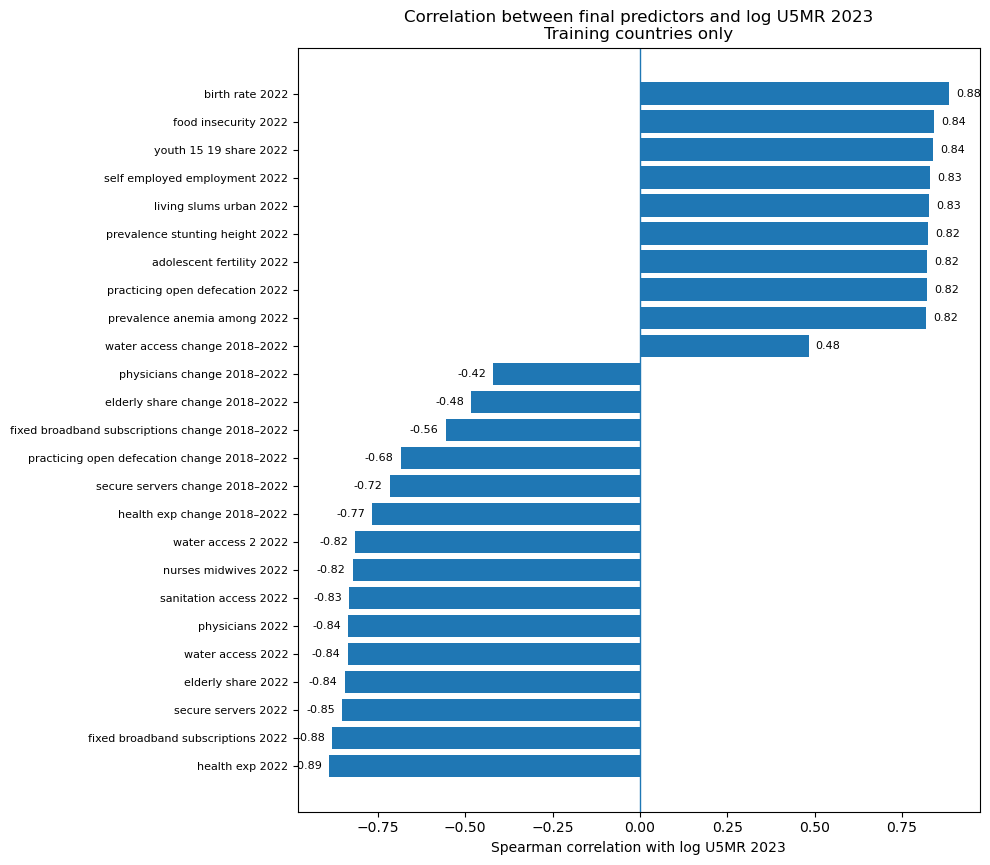

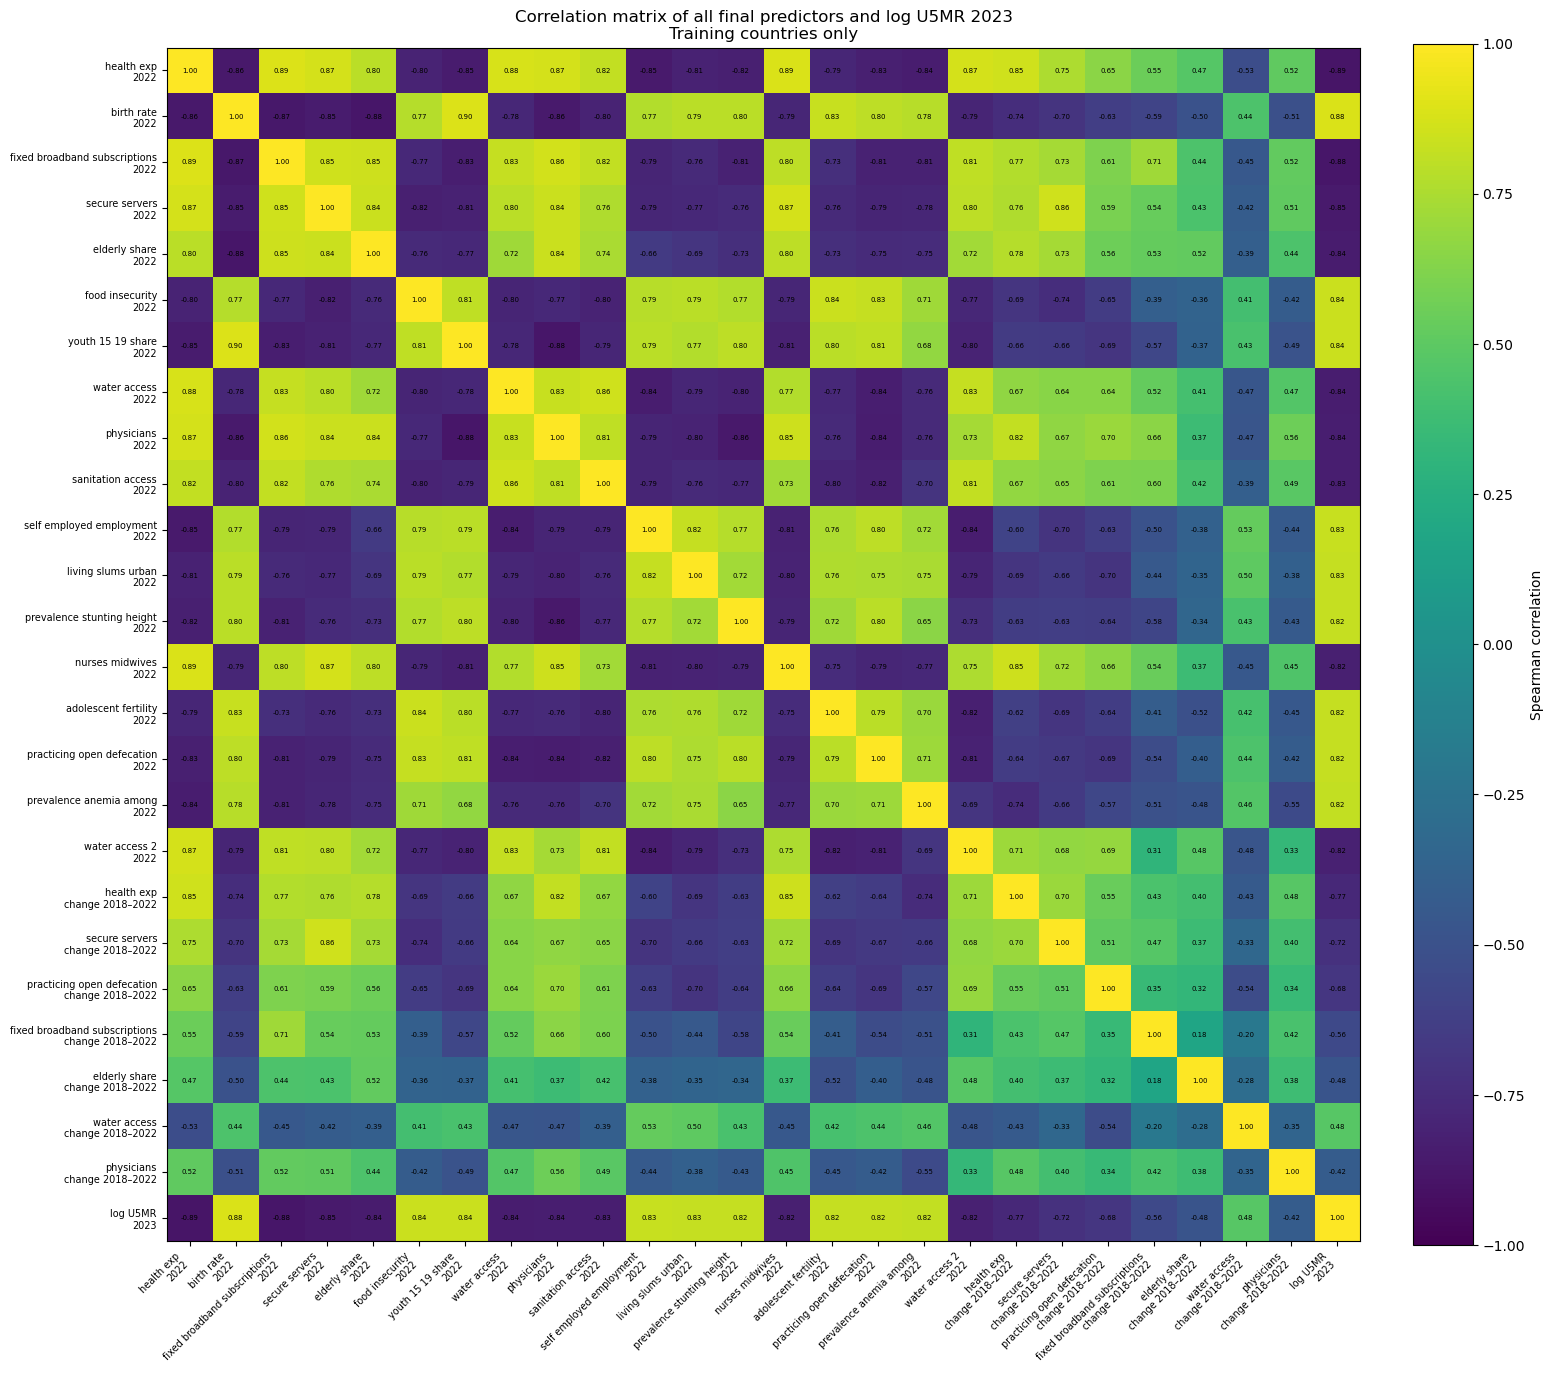

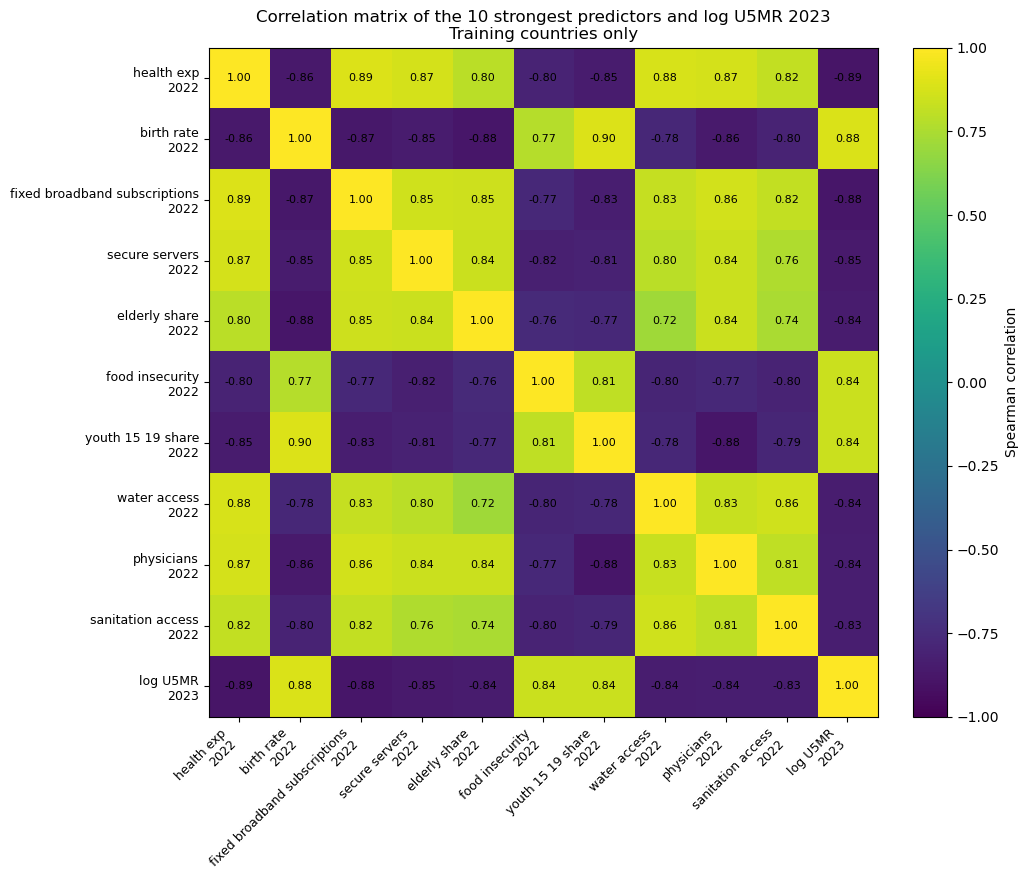

In [699]:
# Compact labels used only for plots.
def compact_feature_label(feature):
    if feature == "log_u5mr_2023":
        return "log U5MR\n2023"

    row = feature_dictionary.set_index("feature").loc[feature]
    base = row["predictor_name"].replace("_", " ")

    if feature.endswith(f"_change_{CHANGE_START_YEAR}_{CHANGE_END_YEAR}"):
        return f"{base}\nchange {CHANGE_START_YEAR}–{CHANGE_END_YEAR}"
    if feature.endswith(f"_{PREDICTOR_LEVEL_YEAR}"):
        return f"{base}\n{PREDICTOR_LEVEL_YEAR}"
    return feature.replace("_", " ")

train_model_data_for_corr = model_data[model_data["country_code"].isin(train_codes)].copy()

# Correlation of every final predictor with the target.
corr_to_target = (
    train_model_data_for_corr[kept_feature_columns + ["log_u5mr_2023"]]
    .corr(method="spearman")["log_u5mr_2023"]
    .drop("log_u5mr_2023")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

corr_table = pd.DataFrame({
    "feature": corr_to_target.index,
    "plot_label": [compact_feature_label(feature).replace("\n", " ") for feature in corr_to_target.index],
    "spearman_corr_with_log_u5mr": corr_to_target.values,
    "abs_corr": corr_to_target.abs().values
}).merge(
    feature_dictionary[["feature", "predictor_name", "domain", "indicator_code", "indicator_name"]],
    on="feature",
    how="left"
)

corr_table.to_csv(TABLE_DIR / "final_predictor_correlations_training_only.csv", index=False)

print("Final engineered predictors included in the model:", len(kept_feature_columns))
display(corr_table[[
    "predictor_name",
    "domain",
    "feature",
    "spearman_corr_with_log_u5mr"
]])

# Bar plot: every final predictor ranked by correlation with the target.
plot_corr = corr_table.sort_values("spearman_corr_with_log_u5mr").copy()

fig, ax = plt.subplots(figsize=(10, max(6, 0.35 * len(plot_corr))))
y_pos = np.arange(len(plot_corr))
ax.barh(y_pos, plot_corr["spearman_corr_with_log_u5mr"])
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_corr["plot_label"], fontsize=8)
ax.axvline(0, linewidth=1)
ax.set_xlabel("Spearman correlation with log U5MR 2023")
ax.set_title("Correlation between final predictors and log U5MR 2023\nTraining countries only")

for i, value in enumerate(plot_corr["spearman_corr_with_log_u5mr"]):
    offset = 0.02 if value >= 0 else -0.02
    ha = "left" if value >= 0 else "right"
    ax.text(value + offset, i, f"{value:.2f}", va="center", ha=ha, fontsize=8)

plt.tight_layout()
plt.savefig(VIS_DIR / "final_predictor_target_correlations_training_only.png", dpi=300)
plt.show()

# Full correlation matrix for all final predictors.
full_matrix_cols = kept_feature_columns + ["log_u5mr_2023"]
full_corr_matrix = train_model_data_for_corr[full_matrix_cols].corr(method="spearman")
full_matrix_labels = [compact_feature_label(col) for col in full_matrix_cols]

matrix_size = len(full_matrix_cols)
fig_width = max(13, 0.60 * matrix_size)
fig_height = max(11, 0.55 * matrix_size)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
im = ax.imshow(full_corr_matrix.values, vmin=-1, vmax=1, aspect="equal")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman correlation")

ax.set_xticks(np.arange(matrix_size))
ax.set_yticks(np.arange(matrix_size))
ax.set_xticklabels(full_matrix_labels, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(full_matrix_labels, fontsize=7)
ax.set_title("Correlation matrix of all final predictors and log U5MR 2023\nTraining countries only")

for i in range(matrix_size):
    for j in range(matrix_size):
        value = full_corr_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=5)

plt.tight_layout()
plt.savefig(VIS_DIR / "all_final_predictors_correlation_matrix_training_only.png", dpi=300)
plt.show()

# Smaller matrix for strongest predictors only.
TOP_N_MATRIX = min(10, len(kept_feature_columns))

top_matrix_features = corr_table.head(TOP_N_MATRIX)["feature"].tolist()
top_matrix_cols = top_matrix_features + ["log_u5mr_2023"]
top_corr_matrix = train_model_data_for_corr[top_matrix_cols].corr(method="spearman")
top_matrix_labels = [compact_feature_label(col) for col in top_matrix_cols]

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(top_corr_matrix.values, vmin=-1, vmax=1, aspect="equal")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman correlation")

ax.set_xticks(np.arange(len(top_matrix_cols)))
ax.set_yticks(np.arange(len(top_matrix_cols)))
ax.set_xticklabels(top_matrix_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(top_matrix_labels, fontsize=9)
ax.set_title(
    f"Correlation matrix of the {TOP_N_MATRIX} strongest predictors and log U5MR 2023\n"
    "Training countries only"
)

for i in range(len(top_matrix_cols)):
    for j in range(len(top_matrix_cols)):
        value = top_corr_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(VIS_DIR / "top_final_predictors_correlation_matrix_training_only.png", dpi=300)
plt.show()


## 7.9 Save final cross-sectional modeling data

In [701]:
model_data.to_csv(DATA_DIR / "final_cross_sectional_model_data_leakage_safe_year_named.csv", index=False)
train_model_data = model_data[model_data["country_code"].isin(train_codes)].copy()
test_model_data = model_data[model_data["country_code"].isin(test_codes)].copy()
train_model_data.to_csv(DATA_DIR / "train_model_data.csv", index=False)
test_model_data.to_csv(DATA_DIR / "test_model_data.csv", index=False)

print("Final model_data shape:", model_data.shape)
print("Train model_data shape:", train_model_data.shape)
print("Test model_data shape:", test_model_data.shape)

Final model_data shape: (196, 29)
Train model_data shape: (147, 29)
Test model_data shape: (49, 29)
